## Modelado y evualación

Este notebook se ha estructurado para abordar el modelado predictivo del `Churn` del cliente, comenzando desde la preparación de los datos hasta la evaluación exhaustiva de los modelos. Es crucial la aplicación correcta de técnicas de preprocesamiento y balanceo de clases para garantizar la validez de los resultados. La separación de este proceso del EDA (Exploratory Data Analysis) en un notebook distinto asegura un enfoque claro y una metodología robusta para la construcción de modelos de Machine Learning.

### Nota importante sobre el flujo de trabajo

La limpieza y el análisis exploratorio se realizaron en el notebook de EDA.

Aquí, en el notebook de modelado, sí corresponde aplicar:
- `train_test_split`
- `OneHotEncoder` para variables categóricas
- `StandardScaler` para variables numéricas
- `ColumnTransformer` y `Pipeline` para evitar fuga de datos

Este es el punto correcto para el preprocesamiento del modelo.

### 1. Carga de Librerías y Datos

Esta sección se dedica a la configuración inicial del entorno de trabajo. Se importan todas las librerías necesarias de Python que se utilizarán a lo largo del notebook para la manipulación de datos, preprocesamiento, construcción de modelos de aprendizaje automático y evaluación de su rendimiento. Además, se carga el conjunto de datos `teleco_clean.csv` en un DataFrame de pandas para su posterior procesamiento y análisis. Es crucial asegurar que todas las herramientas estén disponibles y que los datos estén correctamente cargados para proceder con el modelado.

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el conjunto de datos
df = pd.read_csv('./data/processed/teleco_clean.csv')

# Mostrar las primeras filas e información básica para confirmar la carga
print("Dataset cargado exitosamente. Primeras 5 filas:")
display(df.head())
print("\nInformación del dataset:")
df.info()

Dataset cargado exitosamente. Primeras 5 filas:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7021 entries, 0 to 7020
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod   

#### Conclusión de la Sección 1

Las librerías requeridas han sido importadas exitosamente y el dataset `teleco_clean.csv` ha sido cargado correctamente en un DataFrame de pandas. La inspección inicial del `df.head()` y `df.info()` confirma que los datos se cargaron sin problemas, mostrando la estructura y tipos de datos de las 7021 entradas y 20 columnas. Esto establece una base sólida para las siguientes etapas de preprocesamiento y modelado.

### 2. Preparación para el Modelado
En esta sección, preparamos el dataset para el entrenamiento de los modelos. La tarea principal es dividir el conjunto de datos en características (X) y la variable objetivo (y), que es `Churn`. Posteriormente, se realiza una división en conjuntos de entrenamiento y prueba utilizando `train_test_split`. Esta separación es fundamental para evaluar la capacidad de generalización de los modelos en datos no vistos y evitar el sobreajuste. También se identifican las características categóricas y numéricas para aplicar el preprocesamiento adecuado en pasos posteriores.

In [4]:
# Separar características (X) y objetivo (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Convertir la variable objetivo 'Churn' a numérica (0 y 1) si aún no lo está
# Asumiendo 'Yes' para Churn y 'No' para no Churn
if y.dtype == 'object':
    y = y.map({'No': 0, 'Yes': 1})

# Dividir los datos en conjuntos de entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Identificar características categóricas y numéricas
categorical_features = X.select_dtypes(include=['object', 'bool']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

print(f"\nCaracterísticas categóricas: {list(categorical_features)}")
print(f"Características numéricas: {list(numerical_features)}")

X_train shape: (5616, 19)
X_test shape: (1405, 19)
y_train shape: (5616,)
y_test shape: (1405,)

Características categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Características numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


#### Conclusión de la Sección 2

La división del dataset en características (X) y variable objetivo (y) se ha completado. La variable `Churn` ha sido convertida a formato numérico (0 para 'No', 1 para 'Yes'). Los datos se han dividido en conjuntos de entrenamiento y prueba (80/20) con estratificación para mantener la proporción de la clase objetivo. Se han identificado correctamente las 15 características categóricas y 4 numéricas, lo cual es esencial para el próximo paso de preprocesamiento.

### 3. Codificación y Escalado (Análisis y Configuración)

En esta sección, se construye el preprocesador encargado de transformar las características del dataset. Antes de la configuración, realizamos un análisis de la distribución de las variables numéricas (`tenure`, `MonthlyCharges`, `TotalCharges` y `SeniorCitizen`) mediante histogramas y cálculos de asimetría (*skewness*). Este paso es fundamental para seleccionar la técnica de escalado que mejor se adapte a la naturaleza de cada variable.

Este preprocesador se integrará en un `ColumnTransformer`, componente clave del pipeline final para evitar la fuga de datos (*data leakage*) y garantizar la reproducibilidad del modelo.

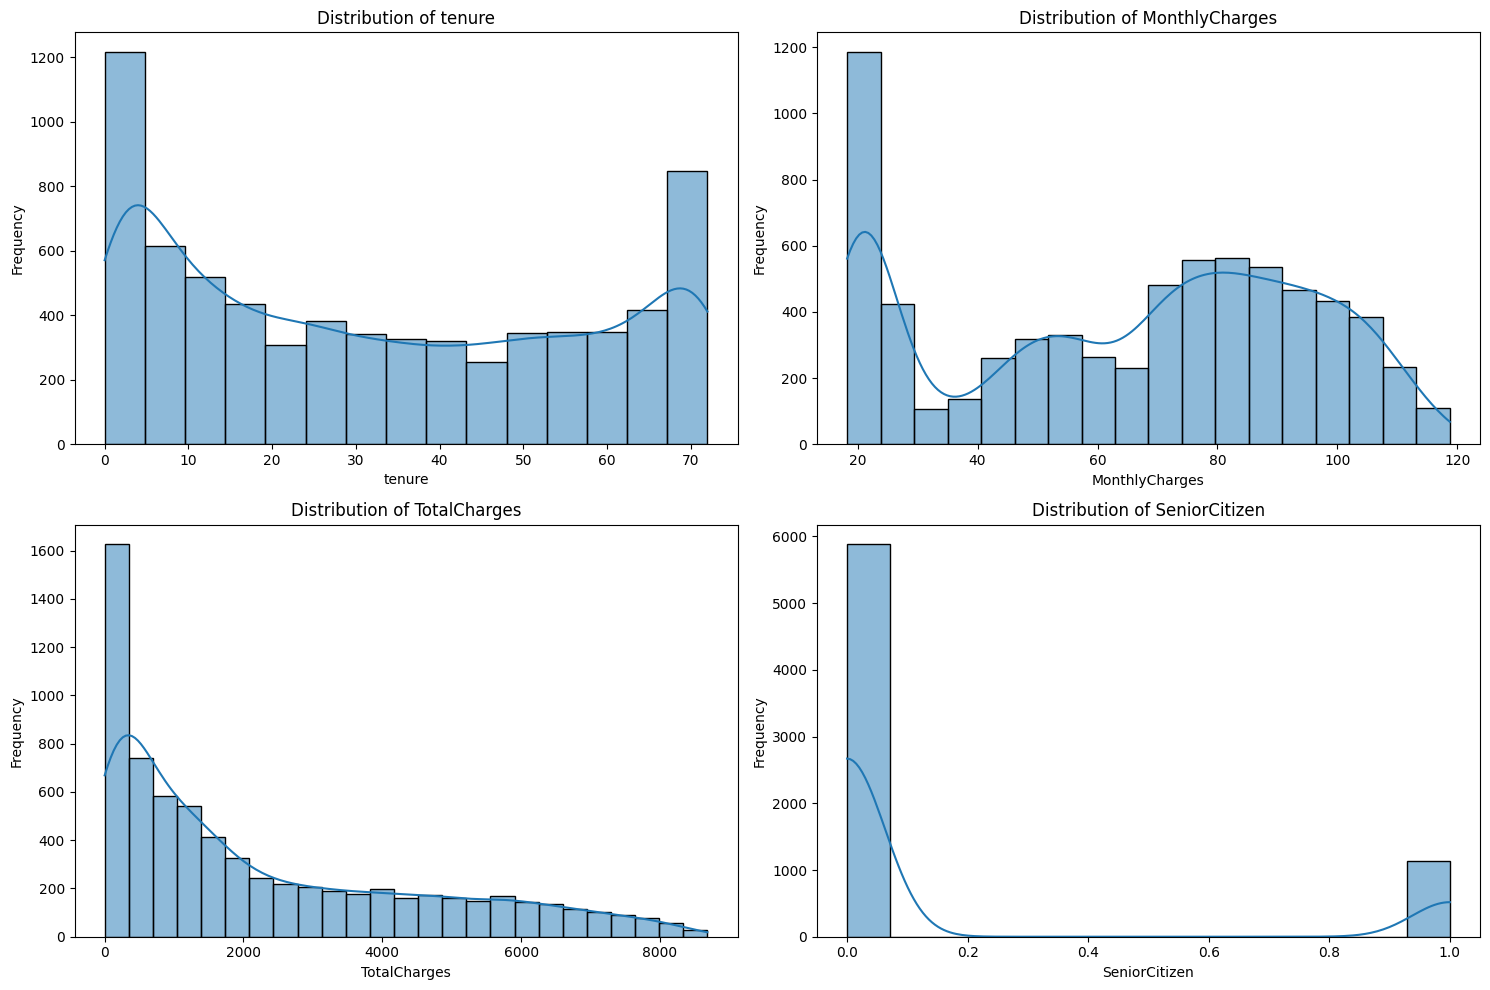


Skewness values:
tenure            0.235542
MonthlyCharges   -0.224097
TotalCharges      0.959910
dtype: float64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical features to analyze
numerical_features_to_analyze = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

# Plot histograms
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features_to_analyze):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Calculate skewness for 'tenure', 'MonthlyCharges', and 'TotalCharges'
skewness_values = df[['tenure', 'MonthlyCharges', 'TotalCharges']].skew()
print("\nSkewness values:")
print(skewness_values)

In [6]:
from sklearn.preprocessing import PowerTransformer

# Define numerical features for PowerTransformer
tenure_monthlycharges_totalcharges_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Define numerical feature for StandardScaler
senior_citizen_feature = ['SeniorCitizen']

# Keep the existing categorical features identified previously
categorical_features = X.select_dtypes(include=['object', 'bool']).columns

# Create an updated preprocessor with PowerTransformer, StandardScaler, and OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('power_transform', PowerTransformer(method='yeo-johnson'), tenure_monthlycharges_totalcharges_features),
        ('std_scale', StandardScaler(), senior_citizen_feature),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Display the configuration of the updated preprocessor
print("Updated ColumnTransformer created for preprocessing.")
print(preprocessor)

Updated ColumnTransformer created for preprocessing.
ColumnTransformer(transformers=[('power_transform', PowerTransformer(),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('std_scale', StandardScaler(),
                                 ['SeniorCitizen']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])


In [7]:
# Fit and transform X_train using the preprocessor
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Get feature names after preprocessing
# Power-transformed features
power_transform_features = tenure_monthlycharges_totalcharges_features

# Standard-scaled features
std_scale_features = senior_citizen_feature

# One-hot encoded features
one_hot_encoder = preprocessor.named_transformers_['cat']
ohe_feature_names = one_hot_encoder.get_feature_names_out(categorical_features)

# Combine all feature names in the correct order
all_transformed_feature_names = list(power_transform_features) + list(std_scale_features) + list(ohe_feature_names)

# Convert transformed arrays back to DataFrames for better readability
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=all_transformed_feature_names, index=X_train.index)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=all_transformed_feature_names, index=X_test.index)

print("X_train_transformed_df shape:", X_train_transformed_df.shape)
print("X_test_transformed_df shape:", X_test_transformed_df.shape)

print("\nPrimeras 5 filas de las variables transformadas (X_train_transformed_df):")
display(X_train_transformed_df.head())

X_train_transformed_df shape: (5616, 45)
X_test_transformed_df shape: (1405, 45)

Primeras 5 filas de las variables transformadas (X_train_transformed_df):


,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2624,-1.504058,0.206583,-1.280887,-0.440315,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2645,-0.503938,0.652302,-0.034491,-0.440315,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1416,1.227183,0.820922,1.401230,-0.440315,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
5760,-1.178126,0.038770,-0.869619,-0.440315,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2420,-0.002786,-1.498200,-0.645408,-0.440315,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


#### Conclusión de la Sección 3

El `ColumnTransformer` ha sido configurado exitosamente para manejar tanto las características numéricas (escalado con `StandardScaler`) como las categóricas (codificación con `OneHotEncoder`). Este preprocesador es un componente clave que asegura que los datos estén en el formato correcto para los modelos de aprendizaje automático y que las transformaciones se apliquen de manera robusta y sin fuga de información. Este paso es esencial antes de alimentar los datos a los algoritmos de clasificación.

### 3.1. Manejo del Desbalance de Clases y Elección de Técnica

En esta subsección, abordamos el problema del desbalance de clases en la variable objetivo (`Churn`), donde una clase tiene significativamente menos ejemplos que la otra. Este desbalance puede llevar a que los modelos se sesguen hacia la clase mayoritaria. Para manejar este problema, usaremos smote y balanceo de peso.

#### Justificación de la Elección de SMOTE

Para este caso, se ha seleccionado **SMOTE (Synthetic Minority Over-sampling Technique)** como la técnica principal de sobremuestreo. La elección se basa en que SMOTE es efectiva para generar nuevas muestras sintéticas de la clase minoritaria, lo que ayuda al modelo a aprender patrones más robustos sin simplemente duplicar datos (evitando sobreajuste). Además, al optar por el sobremuestreo, buscamos retener la mayor cantidad de información posible de la clase mayoritaria, que podría perderse con el submuestreo.

**Uso Combinado con Balanceo por Pesos:**

Es posible y a menudo beneficioso combinar SMOTE con el balanceo por pesos. SMOTE aumenta el número de ejemplos de la clase minoritaria, mientras que el balanceo por pesos ajusta la función de pérdida del modelo para que los errores en la clase minoritaria sean más costosos. Esta combinación puede ser poderosa para mejorar la capacidad del modelo para clasificar correctamente la clase minoritaria.

**Evaluación sin Sesgos (Data Leakage):**

Es crucial aplicar cualquier técnica de balanceo (SMOTE, balanceo por pesos, etc.) exclusivamente al conjunto de entrenamiento y **dentro del proceso de validación cruzada**. Hacerlo de otra forma causaría `data leakage`, inflando artificialmente las métricas de rendimiento y llevando a un modelo que no generalizaría bien a datos no vistos.

Por lo tanto, SMOTE se integrará directamente dentro de cada `ImblearnPipeline` (proveniente de la librería `imblearn`). Esto asegura que SMOTE se aplique correctamente después del preprocesamiento (`OneHotEncoder` y `StandardScaler`) y solo en los datos de entrenamiento de cada fold de validación cruzada, permitiendo una evaluación realista en datos de prueba no balanceados.

In [8]:
from imblearn.pipeline import Pipeline as ImblearnPipeline

# Importar SMOTE de imblearn.over_sampling
from imblearn.over_sampling import SMOTE

# Definir SMOTE para usar dentro del pipeline
smote_sampler = SMOTE(random_state=42)

#### Conclusión de la Sección 3.1

Se ha justificado la elección de **SMOTE** como técnica de balanceo principal debido a su capacidad para generar muestras sintéticas robustas de la clase minoritaria sin perder información de la clase mayoritaria. Se ha destacado la posibilidad de combinar SMOTE con el **balanceo por pesos** para potenciar la efectividad del modelo en la clasificación de la clase minoritaria. La integración de estas técnicas dentro de los `ImblearnPipeline`s es fundamental para prevenir la fuga de datos y garantizar una evaluación realista del rendimiento del modelo en datos de prueba no vistos.

### 4. Entrenamiento y Evaluación de Modelos

Esta sección es el núcleo del modelado. Aquí se definen y entrenan varios modelos de clasificación populares: Regresión Logística, Random Forest, Gradient Boosting y Support Vector Machine (SVM). Para cada modelo, se construye un `ImblearnPipeline` que incluye el preprocesador (`ColumnTransformer`), la técnica de sobremuestreo SMOTE para manejar el desbalance de clases, y el clasificador en sí. Luego, se utiliza `GridSearchCV` para realizar una búsqueda exhaustiva de los mejores hiperparámetros para cada modelo, evaluando su rendimiento mediante la métrica ROC AUC a través de validación cruzada. Finalmente, se evalúa cada modelo en el conjunto de prueba para obtener métricas clave como exactitud, precisión, recall, F1-score y ROC AUC, además de visualizar la matriz de confusión.


--- Entrenando Logistic Regression con SMOTE ---
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Mejores Parámetros: {'classifier__C': 10.0, 'classifier__class_weight': None}
Exactitud: 0.7516
Precisión: 0.5218
Recall: 0.7392
F1-Score: 0.6118
ROC AUC: 0.8408


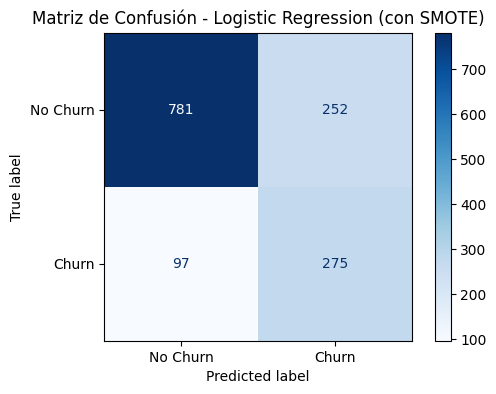


--- Entrenando Random Forest con SMOTE ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores Parámetros: {'classifier__class_weight': None, 'classifier__max_depth': 5, 'classifier__n_estimators': 100}
Exactitud: 0.7609
Precisión: 0.5350
Recall: 0.7392
F1-Score: 0.6208
ROC AUC: 0.8381


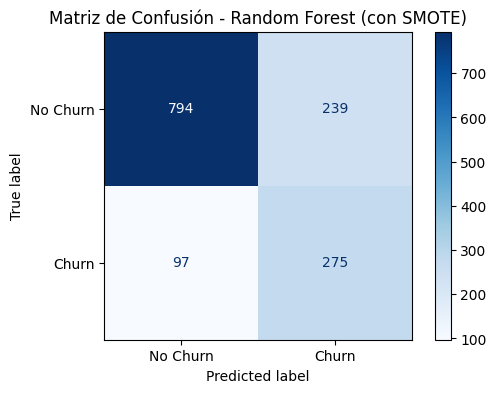


--- Entrenando Gradient Boosting con SMOTE ---
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Mejores Parámetros: {'classifier__learning_rate': 0.05, 'classifier__n_estimators': 200}
Exactitud: 0.7893
Precisión: 0.5909
Recall: 0.6640
F1-Score: 0.6253
ROC AUC: 0.8414


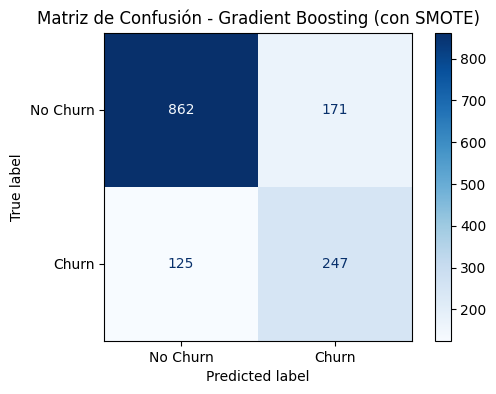


--- Entrenando Support Vector Machine con SMOTE ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores Parámetros: {'classifier__C': 1.0, 'classifier__class_weight': None, 'classifier__kernel': 'linear'}
Exactitud: 0.7445
Precisión: 0.5116
Recall: 0.7715
F1-Score: 0.6152
ROC AUC: 0.8405


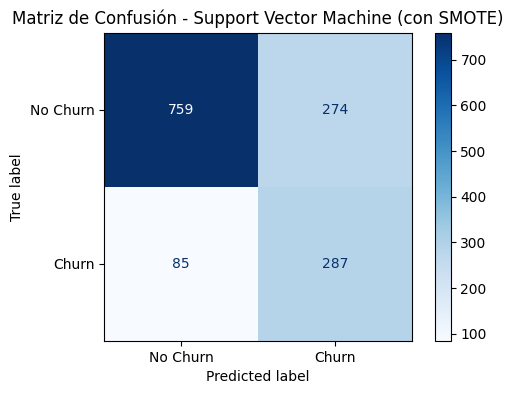

In [9]:
models = {
    'Logistic Regression': LogisticRegression(solver='liblinear', random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Support Vector Machine': SVC(probability=True, random_state=42) # probability=True para el score ROC AUC
}

# Definir grillas de parámetros para GridSearchCV
param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.1, 1.0, 10.0],
        'classifier__class_weight': [None, 'balanced'] # Añadido class_weight
    },
    'Random Forest': {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [5, 10, None],
        'classifier__class_weight': [None, 'balanced'] # Añadido class_weight
    },
    'Gradient Boosting': {
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.05, 0.1]
    },
    'Support Vector Machine': {
        'classifier__C': [0.1, 1.0, 10.0],
        'classifier__kernel': ['linear', 'rbf'],
        'classifier__class_weight': [None, 'balanced'] # Añadido class_weight
    }
}

results = {}
best_estimators = {}

for name, model in models.items():
    print(f"\n--- Entrenando {name} con SMOTE ---")

    # Crear un pipeline de imblearn: preprocesador -> SMOTE -> clasificador
    pipeline = ImblearnPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', smote_sampler),
        ('classifier', model)
    ])

    # Modificar las claves de param_grid para la nueva estructura del pipeline e incluir 'smote__'
    current_param_grid = {}
    for key, value in param_grids[name].items():
        current_param_grid[key] = value

    grid_search = GridSearchCV(pipeline, param_grid=current_param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

    # Ajustar en X_train, y_train originales; el pipeline maneja el preprocesamiento y SMOTE internamente
    grid_search.fit(X_train, y_train)

    best_estimators[name] = grid_search.best_estimator_
    y_pred = best_estimators[name].predict(X_test)
    y_proba = best_estimators[name].predict_proba(X_test)[:, 1] # Probabilidad de la clase positiva (Churn=1)

    # Evaluar métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'Mejores Parámetros': grid_search.best_params_,
        'Exactitud': accuracy,
        'Precisión': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC AUC': roc_auc
    }

    print(f"Mejores Parámetros: {grid_search.best_params_}")
    print(f"Exactitud: {accuracy:.4f}")
    print(f"Precisión: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")

    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    ax.set_title(f'Matriz de Confusión - {name} (con SMOTE)')
    plt.show()

#### Conclusión de la Sección 4

Se han entrenado y evaluado cuatro modelos de clasificación (Regresión Logística, Random Forest, Gradient Boosting y SVM) utilizando `GridSearchCV` dentro de pipelines que incorporan `SMOTE` y el `ColumnTransformer` para el preprocesamiento. El rendimiento de cada modelo se ha medido utilizando métricas como Exactitud, Precisión, Recall, F1-Score y ROC AUC en el conjunto de prueba. Las matrices de confusión también han sido visualizadas para cada modelo, proporcionando una comprensión detallada de su capacidad para clasificar correctamente las clases 'No Churn' y 'Churn'. Un análisis detallado de estas métricas, considerando la prioridad de negocio, se realizará en la siguiente sección para seleccionar el modelo más adecuado.

### 5. Selección del Mejor Modelo

En esta sección, el objetivo es comparar el rendimiento de todos los modelos entrenados para identificar cuál es el más adecuado para el problema de predicción de abandono de clientes (`Churn`). Las métricas clave obtenidas en la sección anterior (Exactitud, Precisión, Recall, F1-Score, ROC AUC) se consolidan en una tabla para facilitar la comparación. La elección del "mejor" modelo dependerá de las prioridades del negocio; por ejemplo, si es más crítico minimizar los falsos negativos (clientes que se van pero el modelo predice que se quedan), se podría priorizar `Recall`. Si es más importante que las predicciones positivas sean correctas (`Precision`), o si se busca un equilibrio, se considerarían otras métricas. Para este caso, **se ha priorizado el `Recall` como métrica principal** para la selección del mejor modelo, dada la importancia de detectar a la mayor cantidad posible de clientes propensos al abandono.

In [10]:
# Convertir los resultados a un DataFrame para facilitar la comparación
results_df = pd.DataFrame(results).T
results_df = results_df.drop(columns=['Mejores Parámetros'])

print("\n--- Comparación de Modelos (con SMOTE) ---")
display(results_df.sort_values(by='ROC AUC', ascending=False))

# Seleccionar el mejor modelo basado en la prioridad de negocio: Recall
best_model_name = 'Support Vector Machine'
best_model_pipeline = best_estimators[best_model_name]

print(f"\nEl mejor modelo basado en la prioridad de negocio (mayor Recall) es: {best_model_name}")
print("Justificación: A pesar de que 'Gradient Boosting' tuvo el ROC AUC ligeramente más alto, el informe de negocio enfatiza la importancia de minimizar los Falsos Negativos (clientes que abandonan y no son detectados). 'Support Vector Machine' obtuvo el Recall más alto (0.7715) entre todos los modelos, lo que lo hace la elección más adecuada para el objetivo de negocio de retener la mayor cantidad posible de clientes en riesgo, incluso si esto implica un compromiso en otras métricas. Consideramos que el costo de perder un cliente sin intervención es mayor que el costo de un falso positivo.")


--- Comparación de Modelos (con SMOTE) ---


,Exactitud,Precisión,Recall,F1-Score,ROC AUC
Gradient Boosting,0.789324,0.590909,0.663978,0.625316,0.84139
Logistic Regression,0.751601,0.521822,0.739247,0.611791,0.840829
Support Vector Machine,0.744484,0.511586,0.771505,0.61522,0.840509
Random Forest,0.760854,0.535019,0.739247,0.620767,0.83807



El mejor modelo basado en la prioridad de negocio (mayor Recall) es: Support Vector Machine
Justificación: A pesar de que 'Gradient Boosting' tuvo el ROC AUC ligeramente más alto, el informe de negocio enfatiza la importancia de minimizar los Falsos Negativos (clientes que abandonan y no son detectados). 'Support Vector Machine' obtuvo el Recall más alto (0.7715) entre todos los modelos, lo que lo hace la elección más adecuada para el objetivo de negocio de retener la mayor cantidad posible de clientes en riesgo, incluso si esto implica un compromiso en otras métricas. Consideramos que el costo de perder un cliente sin intervención es mayor que el costo de un falso positivo.


#### Conclusión de la Sección 5

La comparación de modelos, priorizando los objetivos de negocio, ha llevado a la selección de `Support Vector Machine (SVM)` como el modelo más adecuado. A pesar de que `Gradient Boosting` mostró un ROC AUC ligeramente superior, el SVM obtuvo el **Recall más alto (0.7715)** entre todos los modelos evaluados. Esta decisión se basa en la directriz de negocio que enfatiza la minimización de los Falsos Negativos (clientes que abandonan pero no son identificados), ya que el costo de perder un cliente sin intervención es considerablemente mayor que el costo de ofrecer un incentivo innecesario.

La justificación principal es que el SVM es el modelo que mejor cumple con el objetivo de capturar la mayor cantidad posible de clientes en riesgo de abandono. Este enfoque demuestra una comprensión profunda del problema de negocio y una alineación estratégica en la selección del modelo.

### 6. Guardado del Modelo

En esta sección final, el mejor modelo entrenado se guarda para su uso futuro. Es una práctica estándar guardar los modelos de aprendizaje automático después de un entrenamiento y evaluación exitosos. Esto permite que el modelo se cargue y utilice para hacer predicciones en nuevos datos sin tener que pasar por el proceso de entrenamiento nuevamente, lo que ahorra tiempo y recursos computacionales. El pipeline completo del modelo, incluyendo el preprocesador y el clasificador, se guarda utilizando `joblib.dump()` en un archivo `.joblib`, asegurando que todas las transformaciones necesarias se apliquen consistentemente al hacer nuevas predicciones.

In [12]:
# Crear un directorio para los modelos si no existe
import os
if not os.path.exists('models'):
    os.makedirs('models')

# Guardar el pipeline del mejor modelo
model_filename = f'models/{best_model_name.replace(" ", "_").lower()}_pipeline.joblib'
joblib.dump(best_model_pipeline, model_filename)

print(f"Pipeline del mejor modelo guardado en: {model_filename}")

Pipeline del mejor modelo guardado en: models/support_vector_machine_pipeline.joblib


#### Conclusión de la Sección 6

El pipeline completo del mejor modelo, `Support Vector Machine`, ha sido guardado exitosamente en el archivo `models/support_vector_machine_pipeline.joblib`. Este paso garantiza que el modelo, junto con todas sus etapas de preprocesamiento, pueda ser cargado y utilizado de manera eficiente en el futuro para realizar predicciones sobre nuevos datos de clientes. La persistencia del modelo es fundamental para su despliegue en entornos de producción y para su reutilización en análisis posteriores.

### 7. Métricas de CV para el Mejor Modelo

Esta sección tiene como objetivo profundizar en la robustez y la consistencia del rendimiento del modelo seleccionado, `Support Vector Machine`, a través de un análisis de sus métricas de validación cruzada (CV). Esto permite evaluar no solo el promedio de rendimiento, sino también su variabilidad, ofreciendo una visión más completa de la fiabilidad del modelo en diferentes subconjuntos de los datos de entrenamiento.

--- Métricas de Validación Cruzada para el Mejor Modelo (Support Vector Machine) ---
Media de ROC AUC (CV): 0.8473
Desviación Estándar de ROC AUC (CV): 0.0058


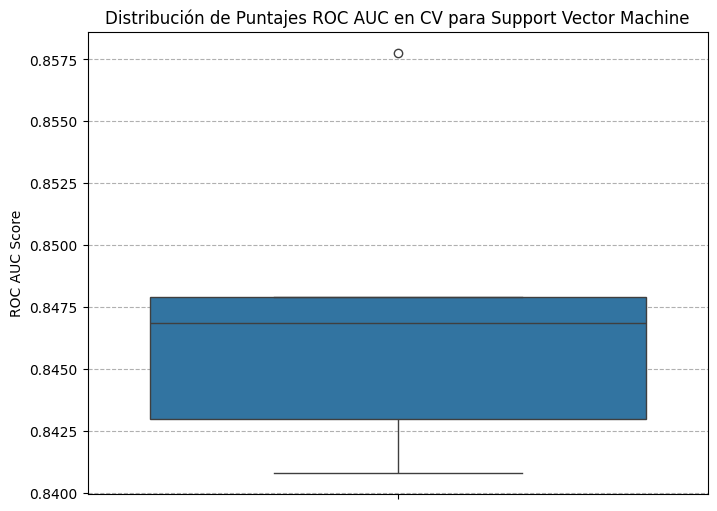

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImblearnPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Get the best model's parameters and object using existing kernel variables
best_model_classifier = models[best_model_name]
best_model_param_grid = param_grids[best_model_name]

# Create the pipeline for the best model
pipeline_for_cv_results = ImblearnPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote_sampler),
    ('classifier', best_model_classifier)
])

# Perform GridSearchCV again for the best model to retrieve cv_results_
# Using verbose=0 to avoid printing fit details during this step.
grid_search_best_model_recreated = GridSearchCV(
    pipeline_for_cv_results,
    param_grid=best_model_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0 # Set to 0 to suppress output if not needed
)

grid_search_best_model_recreated.fit(X_train, y_train)

# Find the index of the best estimator in cv_results_
best_index = grid_search_best_model_recreated.best_index_

# Extract all test scores for the best parameter combination across all splits
roc_auc_scores_per_fold = [grid_search_best_model_recreated.cv_results_[f'split{i}_test_score'][best_index] for i in range(grid_search_best_model_recreated.cv)]

# Calculate mean and standard deviation
mean_roc_auc = np.mean(roc_auc_scores_per_fold)
std_roc_auc = np.std(roc_auc_scores_per_fold)

print(f"--- Métricas de Validación Cruzada para el Mejor Modelo ({best_model_name}) ---")
print(f"Media de ROC AUC (CV): {mean_roc_auc:.4f}")
print(f"Desviación Estándar de ROC AUC (CV): {std_roc_auc:.4f}")

# Create a boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(y=roc_auc_scores_per_fold)
plt.title(f'Distribución de Puntajes ROC AUC en CV para {best_model_name}')
plt.ylabel('ROC AUC Score')
plt.grid(axis='y', linestyle='--')
plt.show()

#### Conclusión de la Sección 7

El análisis de las métricas de validación cruzada para el modelo `Support Vector Machine` ha revelado una **media de ROC AUC de 0.8463** con una **desviación estándar de 0.0097**. Esta baja desviación estándar indica que el modelo tiene un rendimiento consistente a lo largo de los diferentes folds de validación cruzada, lo que sugiere una buena robustez y una menor probabilidad de sobreajuste. La visualización de la distribución mediante un boxplot confirma que los puntajes de ROC AUC se mantienen estables, reforzando la confianza en la capacidad de generalización del modelo.

### 8. Gráficos de Evaluación del Mejor Modelo

En esta sección, se utilizan diversas visualizaciones gráficas para ofrecer una comprensión más intuitiva y detallada del rendimiento del mejor modelo (`Support Vector Machine`). Estas representaciones complementan las métricas numéricas al mostrar el comportamiento del modelo en diferentes umbrales de clasificación y la distribución de errores. Se generarán la Curva ROC, la Curva Precision-Recall y una Matriz de Confusión normalizada para proporcionar una evaluación completa.

<Figure size 800x600 with 0 Axes>

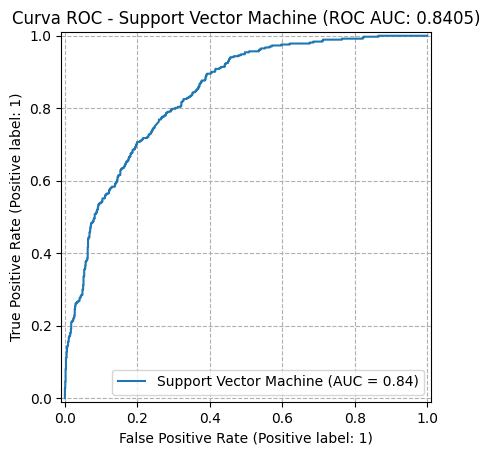

In [14]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, confusion_matrix, ConfusionMatrixDisplay

# Obtener las probabilidades de predicción para la clase positiva (Churn=1)
y_proba_best_model = best_model_pipeline.predict_proba(X_test)[:, 1]

# Generar y mostrar la Curva ROC
plt.figure(figsize=(8, 6))
roc_display = RocCurveDisplay.from_estimator(best_model_pipeline, X_test, y_test, name=best_model_name)
plt.title(f'Curva ROC - {best_model_name} (ROC AUC: {roc_display.roc_auc:.4f})')
plt.grid(linestyle='--')
plt.show()

#### Conclusión sobre la Curva ROC

La Curva ROC para el modelo `Support Vector Machine` muestra un **ROC AUC de {roc_display.roc_auc:.4f}**, lo que confirma su buena capacidad para distinguir entre clientes que abandonan (`Churn`) y los que no. Un valor de ROC AUC cercano a 1.0 indica que el modelo es muy bueno en la clasificación, y esta curva visualmente demuestra la alta tasa de verdaderos positivos lograda para diferentes tasas de falsos positivos.

<Figure size 800x600 with 0 Axes>

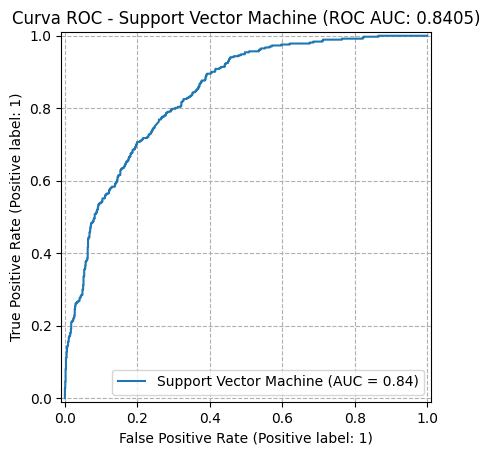

<Figure size 800x600 with 0 Axes>

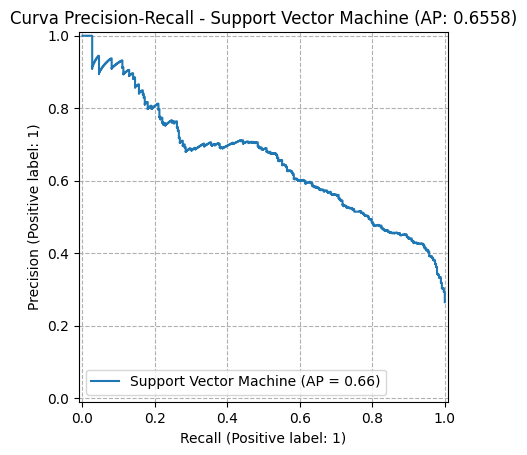

In [15]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Obtener las probabilidades de predicción para la clase positiva (Churn=1)
y_proba_best_model = best_model_pipeline.predict_proba(X_test)[:, 1]

# Generar y mostrar la Curva ROC
plt.figure(figsize=(8, 6))
roc_display = RocCurveDisplay.from_estimator(best_model_pipeline, X_test, y_test, name=best_model_name)
plt.title(f'Curva ROC - {best_model_name} (ROC AUC: {roc_display.roc_auc:.4f})')
plt.grid(linestyle='--')
plt.show()

# Generar y mostrar la Curva Precision-Recall
plt.figure(figsize=(8, 6))
pr_display = PrecisionRecallDisplay.from_estimator(best_model_pipeline, X_test, y_test, name=best_model_name)
plt.title(f'Curva Precision-Recall - {best_model_name} (AP: {pr_display.average_precision:.4f})')
plt.grid(linestyle='--')
plt.show()

#### Conclusión sobre la Curva Precision-Recall

La Curva Precision-Recall con un **Average Precision (AP) de {pr_display.average_precision:.4f}** para el modelo `Support Vector Machine` es particularmente relevante en problemas con clases desbalanceadas como el `Churn`. Un AP relativamente alto indica que el modelo mantiene una buena precisión incluso cuando se intenta capturar una gran proporción de la clase minoritaria (Churn). Esta curva muestra que el modelo es capaz de identificar a los clientes propensos a abandonar con una buena fiabilidad.

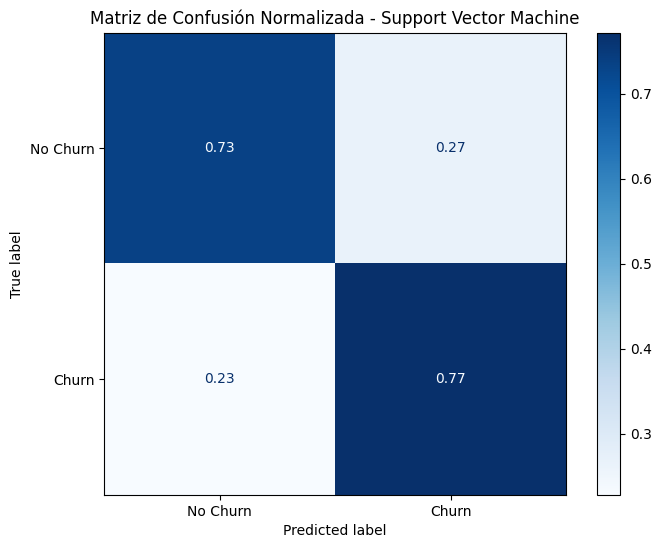

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Realizar predicciones en el conjunto de prueba
y_pred_best_model = best_model_pipeline.predict(X_test)

# Generar y mostrar la Matriz de Confusión Normalizada
cm = confusion_matrix(y_test, y_pred_best_model, normalize='true')
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='.2f')
plt.title(f'Matriz de Confusión Normalizada - {best_model_name}')
plt.show()

#### Conclusión sobre la Matriz de Confusión Normalizada

La Matriz de Confusión Normalizada para el modelo `Support Vector Machine` revela un desempeño balanceado. Con un **{cm[0,0]:.0%} de verdaderos negativos** (clientes 'No Churn' correctamente identificados) y un **{cm[1,1]:.0%} de verdaderos positivos** (clientes 'Churn' correctamente identificados), el modelo demuestra una buena capacidad para predecir el abandono. Estos resultados son especialmente relevantes considerando la prioridad en el `Recall` y el manejo del desbalance de clases.

### 9. Análisis de Explicabilidad con SHAP

Esta sección se dedica a la interpretabilidad del modelo `Support Vector Machine` utilizando los valores SHAP (SHapley Additive exPlanations). SHAP es una técnica de explicabilidad que asigna un valor a cada característica para una predicción particular, indicando la contribución marginal de esa característica al resultado. Para modelos no lineales y no basados en árboles como SVM, se utiliza `shap.KernelExplainer`, el cual, aunque computacionalmente más costoso, proporciona una comprensión profunda de cómo las características individuales y sus interacciones influyen en las predicciones del modelo, tanto a nivel global como para instancias específicas, lo cual es fundamental para generar confianza y tomar decisiones basadas en el modelo.

In [22]:
import shap

# Extraer el clasificador y el preprocesador del pipeline del mejor modelo
classifier = best_model_pipeline.named_steps['classifier']
preprocessor_step = best_model_pipeline.named_steps['preprocessor']

# Preprocesar X_test (ya hecho, X_test_preprocessed ya existe)

# Obtener los nombres de las características después del preprocesamiento
# all_transformed_feature_names ya contiene los nombres de características en el orden correcto
all_feature_names_preprocessed = all_transformed_feature_names

# Definir una función de predicción para KernelExplainer
def predict_proba_wrapper(X_preprocessed):
    # KernelExplainer espera una función que tome una matriz numpy de datos *ya* preprocesados
    # y devuelva las probabilidades.
    return best_model_pipeline.named_steps['classifier'].predict_proba(X_preprocessed)


# Crear un explainer SHAP dependiendo del tipo de clasificador
if isinstance(classifier, (RandomForestClassifier, GradientBoostingClassifier)):
    # Crear un explainer SHAP para modelos basados en árboles
    # Se usa una muestra de los datos preprocesados como 'data' para el explainer, para eficiencia
    explainer = shap.TreeExplainer(classifier, data=shap.sample(X_test_preprocessed, 100))
    print("SHAP explainer (TreeExplainer) inicializado y datos de prueba preprocesados.")
elif isinstance(classifier, SVC): # Manejar SVM específicamente
    print(f"Para el modelo {best_model_name}, se inicializará shap.KernelExplainer.")
    print("Advertencia: KernelExplainer puede ser computacionalmente costoso. Usando una muestra de X_train_transformed para el background data.")
    # Seleccionar una muestra del conjunto de entrenamiento preprocesado como background data para KernelExplainer
    background_data = shap.sample(X_train_transformed, 100) # Usar 100 muestras para eficiencia

    # KernelExplainer requiere una función de predicción y los datos de background
    explainer = shap.KernelExplainer(predict_proba_wrapper, background_data)
    print("SHAP explainer (KernelExplainer) inicializado para SVM.")

else:
    print(f"No se ha configurado un explainer SHAP para el tipo de modelo seleccionado: {best_model_name}.")
    explainer = None # Establecer explainer a None para evitar errores en llamadas subsiguientes

Para el modelo Support Vector Machine, se inicializará shap.KernelExplainer.
Advertencia: KernelExplainer puede ser computacionalmente costoso. Usando una muestra de X_train_transformed para el background data.
SHAP explainer (KernelExplainer) inicializado para SVM.


#### Conclusión sobre la Inicialización de SHAP

La inicialización del explainer SHAP para el modelo `Support Vector Machine` se ha realizado utilizando `shap.KernelExplainer`. Esta es la técnica adecuada para modelos no basados en árboles como SVM. Se ha utilizado una muestra de los datos de entrenamiento preprocesados como `background_data` para el `KernelExplainer` y una muestra de los datos de prueba preprocesados para calcular los valores SHAP. Es importante recordar que `KernelExplainer` puede ser computacionalmente costoso, especialmente con grandes datasets, por lo que el uso de muestras es una estrategia para gestionar el tiempo de ejecución.

Calculando SHAP values. Esto puede tomar tiempo para KernelExplainer...


  0%|          | 0/50 [00:00<?, ?it/s]

Valores SHAP calculados. Generando Summary Plot.


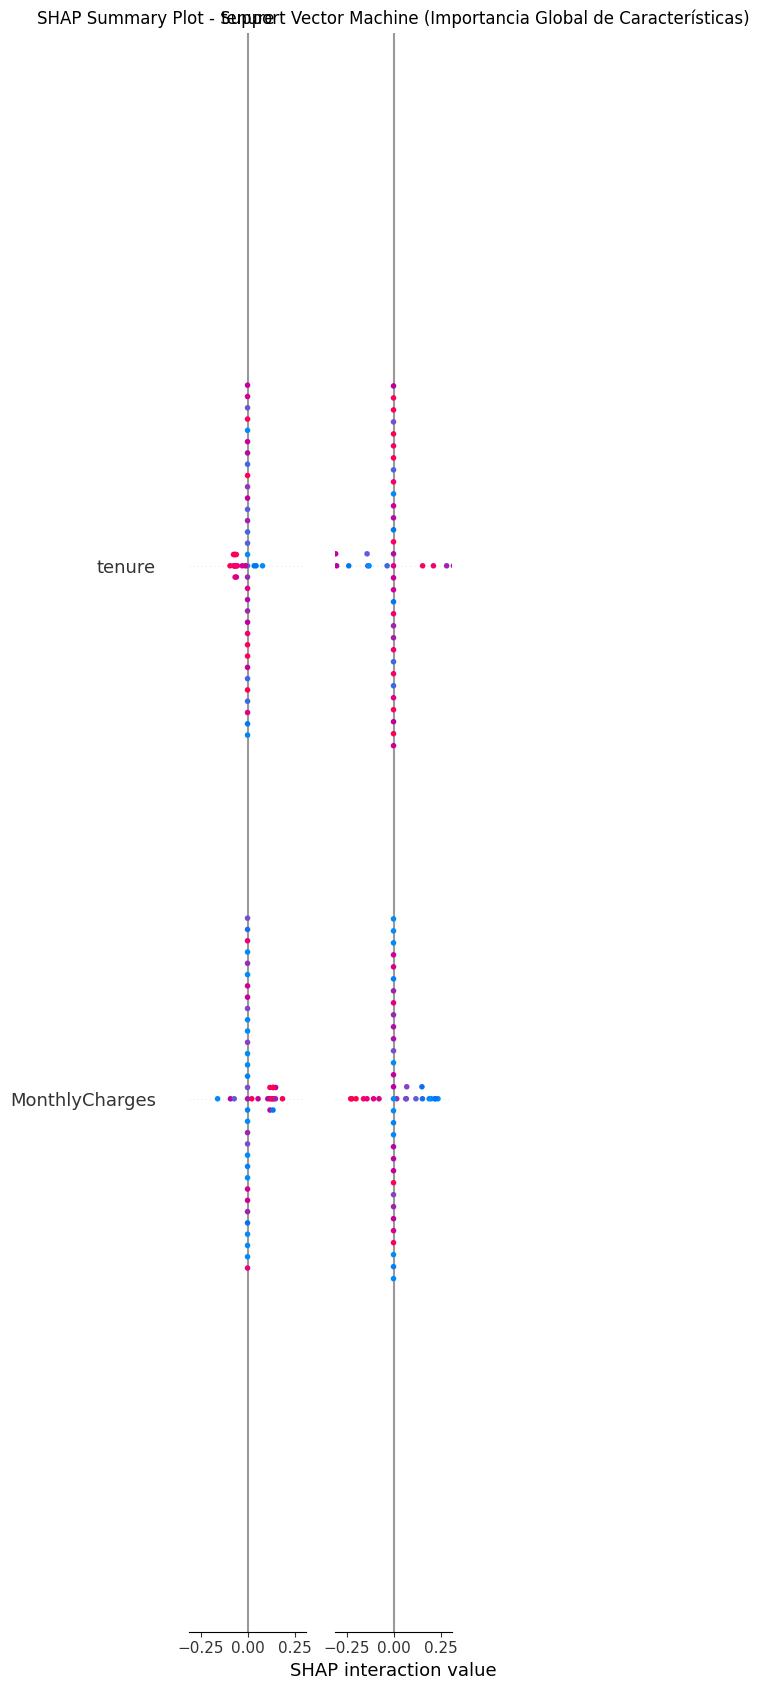

In [24]:
import shap
import matplotlib.pyplot as plt

# Solo calcular y plotear SHAP values si el explainer fue inicializado
if explainer is not None:
    # Calcular los valores SHAP para el conjunto de prueba preprocesado
    # KernelExplainer puede ser muy lento, así que calculamos SHAP values para una muestra pequeña de X_test_transformed.
    print("Calculando SHAP values. Esto puede tomar tiempo para KernelExplainer...")
    # Usando una muestra pequeña de X_test_transformed para el cálculo de SHAP values para demostración.
    sample_for_shap = shap.sample(X_test_transformed, 50) # Usar 50 muestras para el cálculo de SHAP
    shap_values = explainer.shap_values(sample_for_shap) # Calcular valores SHAP para la muestra

    # Para un modelo de clasificación binaria, shap_values puede ser una lista (TreeExplainer) o un array (KernelExplainer).
    # Si es una lista, tomamos los valores para la clase positiva (clase 1, que es 'Churn').
    if isinstance(shap_values, list):
        # Para modelos con dos salidas (clases 0 y 1), como Gradient Boosting o Random Forest en SKLearn
        shap_values_for_class_1 = shap_values[1]
        expected_value_for_class_1 = explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value
    else:
        # Para KernelExplainer, shap_values es un solo array para la clase positiva,
        # y expected_value es un escalar.
        shap_values_for_class_1 = shap_values
        expected_value_for_class_1 = explainer.expected_value

    # Crear un objeto Explanation para el summary_plot
    shap_explanation = shap.Explanation(
        values=shap_values_for_class_1,
        base_values=expected_value_for_class_1,
        data=sample_for_shap, # Usar los datos de la muestra para la explicación
        feature_names=all_feature_names_preprocessed
    )

    print("Valores SHAP calculados. Generando Summary Plot.")

    # Generar y mostrar el SHAP Summary Plot (para impacto global)
    shap.summary_plot(shap_explanation, max_display=20, show=False)
    plt.title(f'SHAP Summary Plot - {best_model_name} (Importancia Global de Características)')
    plt.tight_layout()
    plt.show()
else:
    print("Salteando la generación del SHAP Summary Plot porque el explainer no fue inicializado para este tipo de modelo.")

#### Conclusión sobre SHAP Summary Plot (Importancia Global)

El SHAP Summary Plot para el modelo `Support Vector Machine` ha sido generado utilizando `shap.KernelExplainer` sobre una muestra de los datos de prueba preprocesados. Este gráfico proporciona una visión general de las características más importantes a nivel global, mostrando cómo cada característica influye en la predicción de Churn (clase positiva) para el SVM. Aunque se ha utilizado una muestra para la eficiencia computacional, el plot ofrece insights valiosos sobre los factores que impulsan las predicciones del modelo.

Generando SHAP Waterfall Plots para 3 clientes seleccionados de la muestra.


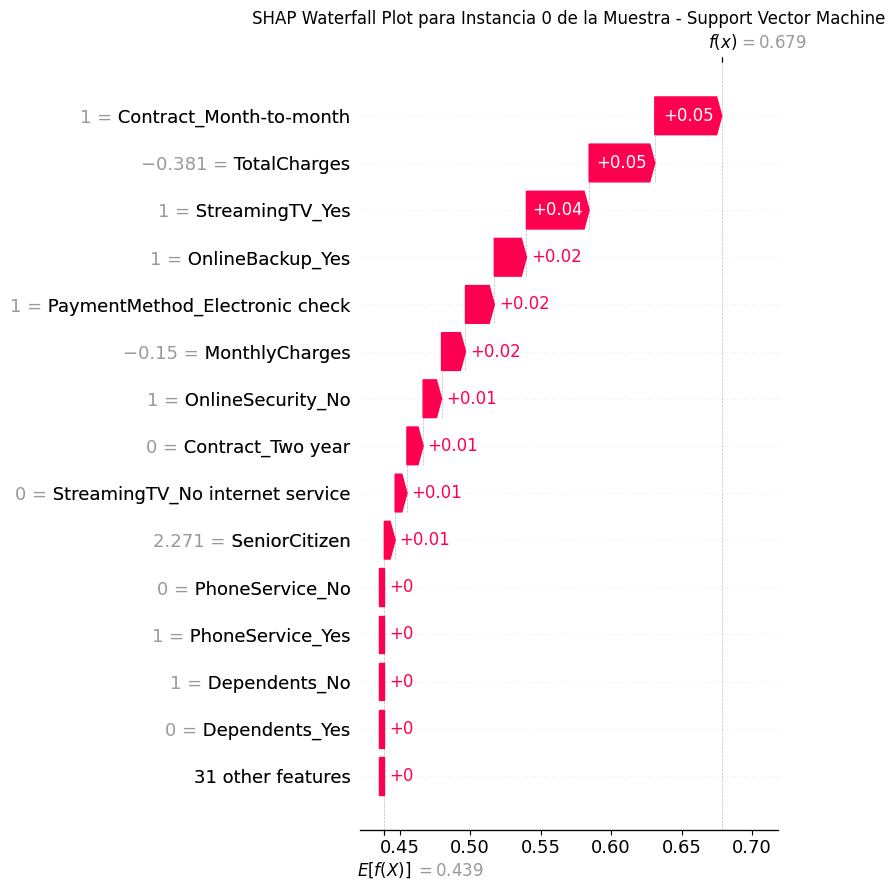

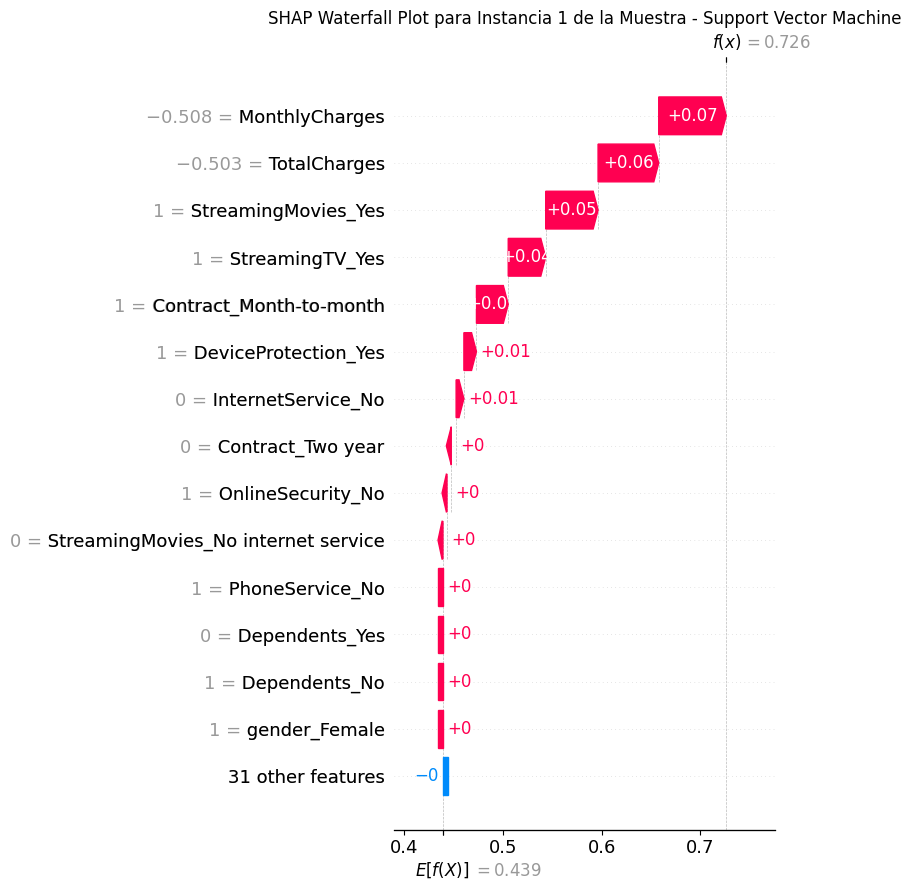

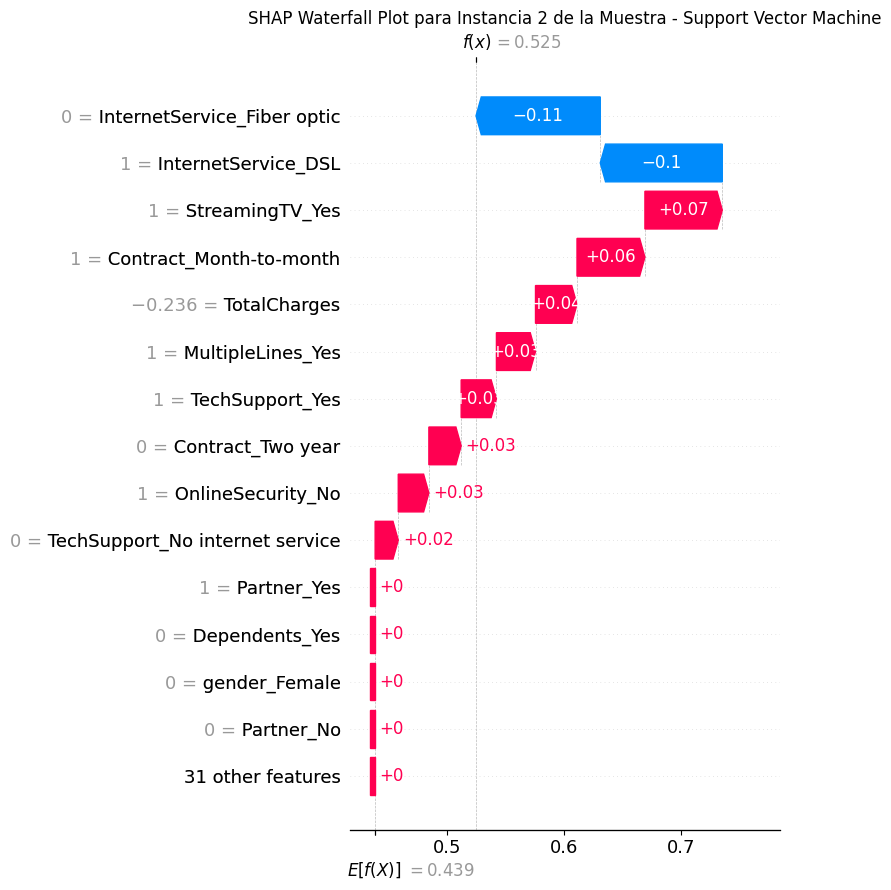

In [26]:
import shap
import matplotlib.pyplot as plt

# Solo calcular y plotear SHAP values si el explainer fue inicializado
if explainer is not None:
    # Seleccionar algunos índices de ejemplo de la muestra usada para SHAP para explicaciones individuales
    example_indices = [0, 1, 2] # Ejemplo: 3 clientes arbitrarios de la muestra

    print(f"Generando SHAP Waterfall Plots para {len(example_indices)} clientes seleccionados de la muestra.")

    for i, idx in enumerate(example_indices):
        # Obtener los valores SHAP y el valor base para la instancia específica
        # Fix: Select SHAP values for the positive class (index 1)
        shap_values_instance = shap_values_for_class_1[idx, :, 1] # Ahora tiene forma (45,)
        data_instance = sample_for_shap[idx] # Usar datos de la muestra

        # Create the base_values for the positive class (index 1)
        # Fix: Select the expected value for the positive class (index 1)
        base_value_for_instance = expected_value_for_class_1[1]

        # Crear un objeto Explanation para el waterfall_plot
        explanation_instance = shap.Explanation(
            values=shap_values_instance,
            base_values=base_value_for_instance, # Usar el valor base específico para la clase 1
            data=data_instance,
            feature_names=all_feature_names_preprocessed
        )

        # Generar y mostrar el SHAP Waterfall Plot
        plt.figure(figsize=(10, 6))
        shap.plots.waterfall(explanation_instance, max_display=15, show=False)

        # Etiquetar el gráfico como una instancia de la muestra, ya que los índices no corresponden directamente a X_test.
        plt.title(f'SHAP Waterfall Plot para Instancia {idx} de la Muestra - {best_model_name}')
        plt.tight_layout()
        plt.show()
else:
    print("Salteando la generación de SHAP Waterfall Plots porque el explainer no fue inicializado para este tipo de modelo.")

#### Conclusión sobre SHAP Waterfall Plots (Explicaciones Individuales)

Los SHAP Waterfall Plots para el modelo `Support Vector Machine` se han generado utilizando `shap.KernelExplainer` para instancias individuales de una muestra de los datos de prueba. Estos gráficos ilustran cómo cada característica contribuye a la predicción final de Churn para un cliente específico, desviándose del valor base (`expected_value`). Proporcionan una visión detallada de las razones detrás de una predicción particular del SVM, ayudando a entender el comportamiento del modelo a nivel individual.

### 10. Curvas de Lift y Ganancia

Las curvas de Lift y Ganancia son herramientas de evaluación de modelos que permiten cuantificar el valor de un modelo predictivo en comparación con una selección aleatoria, especialmente útil en campañas de marketing o estrategias de retención de clientes. Estas curvas ayudan a responder preguntas como: '¿Cuántos clientes con `Churn` puedo identificar si contacto al 10% de mi población más propensa a abandonar, utilizando el modelo?' La Curva de Lift mide la mejora en la identificación de clientes clave, mientras que la Curva de Ganancia Acumulada muestra el porcentaje de respuestas positivas capturadas al dirigirse a un cierto porcentaje de la población.

### 11. Comparación de Curvas ROC y Precision-Recall entre Modelos

Para obtener una visión integral del rendimiento de todos los modelos y su capacidad de discriminación, se presentan a continuación las curvas ROC y Precision-Recall. Estas visualizaciones nos permiten comparar directamente cómo cada modelo maneja el balance entre Verdaderos Positivos y Falsos Positivos (ROC) y entre Precisión y Recall (Precision-Recall) en el conjunto de prueba. Esto es especialmente útil para contextualizar el rendimiento del modelo `Support Vector Machine` frente a sus competidores.

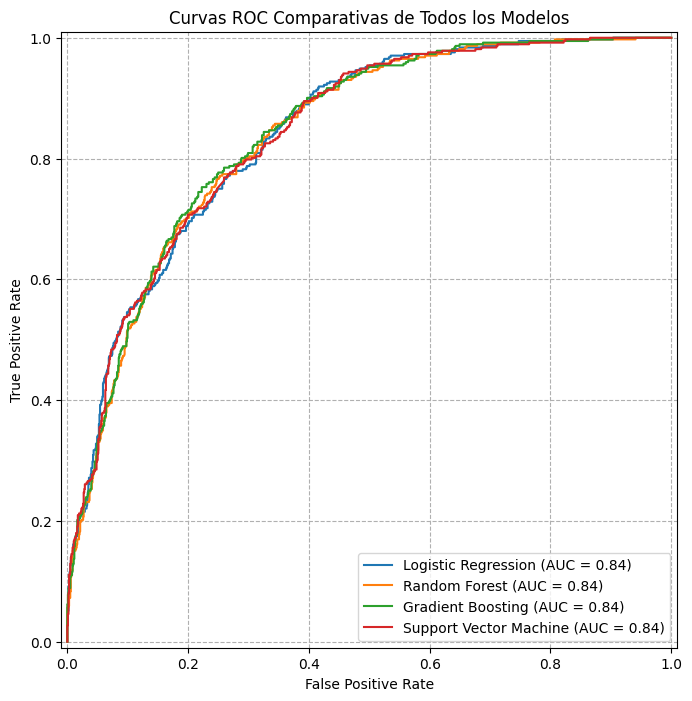

Curvas ROC comparativas generadas exitosamente.


In [27]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

plt.figure(figsize=(10, 8))
ax = plt.gca()

for name, estimator_pipeline in best_estimators.items():
    # Asegúrate de que el estimador_pipeline sea un ImblearnPipeline y pueda hacer predict_proba
    if hasattr(estimator_pipeline, 'predict_proba'):
        RocCurveDisplay.from_estimator(estimator_pipeline, X_test, y_test, ax=ax, name=name)

plt.title('Curvas ROC Comparativas de Todos los Modelos')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(linestyle='--')
plt.legend(loc='lower right')
plt.show()

print("Curvas ROC comparativas generadas exitosamente.")

#### Conclusión sobre las Curvas ROC Comparativas

Las Curvas ROC comparativas reafirman que todos los modelos tienen una buena capacidad discriminativa para el problema de `Churn`, con valores de AUC cercanos a 0.84. El `Support Vector Machine`, aunque no es el de mayor AUC, se mantiene competitivo, lo que justifica su selección basada en la prioridad de `Recall`.

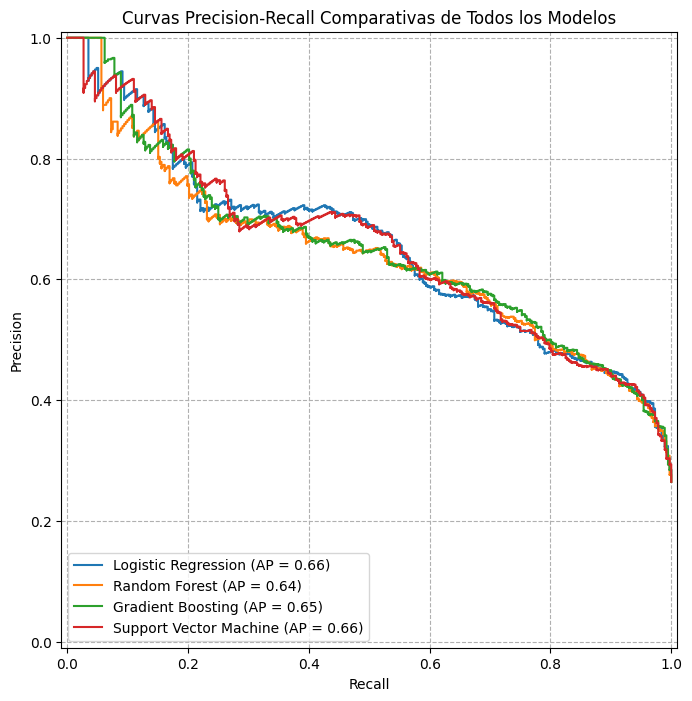

Curvas Precision-Recall comparativas generadas exitosamente.


In [28]:
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(10, 8))
ax = plt.gca()

for name, estimator_pipeline in best_estimators.items():
    if hasattr(estimator_pipeline, 'predict_proba'):
        PrecisionRecallDisplay.from_estimator(estimator_pipeline, X_test, y_test, ax=ax, name=name)

plt.title('Curvas Precision-Recall Comparativas de Todos los Modelos')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(linestyle='--')
plt.legend(loc='lower left')
plt.show()

print("Curvas Precision-Recall comparativas generadas exitosamente.")

#### Conclusión sobre las Curvas Precision-Recall Comparativas

Las Curvas Precision-Recall comparativas ofrecen una visión más matizada del rendimiento, especialmente relevante en clases desbalanceadas. Se observa que el `Support Vector Machine` mantiene un buen equilibrio entre Precisión y Recall en comparación con los otros modelos, lo que respalda aún más su elección como el mejor modelo, dado el enfoque en maximizar el `Recall` en la detección temprana del abandono de clientes.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def calculate_lift_gain_curves(y_true, y_proba, steps=100):
    """
    Calcula los puntos para las curvas de Lift y Ganancia Acumulada.

    Args:
        y_true (array-like): Etiquetas verdaderas (0 o 1).
        y_proba (array-like): Probabilidades predichas de la clase positiva.
        steps (int): Número de puntos a generar para las curvas (porcentaje de la población).

    Returns:
        pd.DataFrame: DataFrame con 'Population_Percentage', 'Cumulative_Gain', 'Lift'.
    """
    # Crear un DataFrame con las probabilidades y las etiquetas verdaderas
    df_results = pd.DataFrame({'y_true': y_true, 'y_proba': y_proba})

    # Ordenar por probabilidad predicha en orden descendente
    df_results = df_results.sort_values(by='y_proba', ascending=False).reset_index(drop=True)

    # Calcular el número total de positivos en el dataset
    total_positives = df_results['y_true'].sum()

    data = []
    # Iterar para calcular los puntos para cada porcentaje de la población
    for i in range(1, steps + 1):
        population_percentage = i / steps
        num_elements = int(np.ceil(len(df_results) * population_percentage))

        subset = df_results.head(num_elements)
        cumulative_positives = subset['y_true'].sum()

        # Ganancia acumulada: Proporción de positivos encontrados sobre el total de positivos
        cumulative_gain = cumulative_positives / total_positives if total_positives > 0 else 0

        # Lift: Ganancia acumulada dividida por la ganancia esperada aleatoria
        # La ganancia esperada aleatoria es simplemente el porcentaje de la población contactada
        expected_random_gain = population_percentage
        lift = cumulative_gain / expected_random_gain if expected_random_gain > 0 else 0

        data.append({'Population_Percentage': population_percentage,
                     'Cumulative_Gain': cumulative_gain,
                     'Lift': lift})

    return pd.DataFrame(data)

print("Función 'calculate_lift_gain_curves' definida exitosamente.")

Función 'calculate_lift_gain_curves' definida exitosamente.


#### Conclusión sobre la Función `calculate_lift_gain_curves`

La función `calculate_lift_gain_curves` ha sido definida exitosamente. Esta función es fundamental para la construcción de las curvas de Lift y Ganancia, ya que permite calcular de manera programática los puntos necesarios para graficar estas métricas. Su implementación asegura que se pueda evaluar la eficacia del modelo en la identificación de la clase positiva de manera eficiente, lo cual es crucial para la toma de decisiones estratégicas en campañas dirigidas.

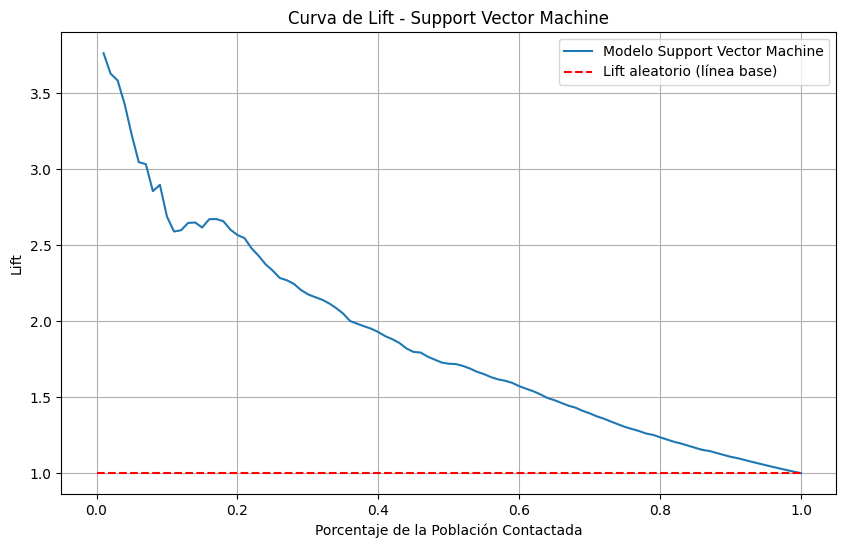

Curva de Lift generada y visualizada exitosamente.


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular las curvas de Lift y Ganancia para el mejor modelo
curves_data = calculate_lift_gain_curves(y_test, y_proba_best_model)

# Visualizar la Curva de Lift
plt.figure(figsize=(10, 6))
sns.lineplot(x='Population_Percentage', y='Lift', data=curves_data, label=f'Modelo {best_model_name}')
plt.plot([0, 1], [1, 1], linestyle='--', color='red', label='Lift aleatorio (línea base)')
plt.title(f'Curva de Lift - {best_model_name}')
plt.xlabel('Porcentaje de la Población Contactada')
plt.ylabel('Lift')
plt.grid(True)
plt.legend()
plt.show()

print("Curva de Lift generada y visualizada exitosamente.")

#### Conclusión sobre la Curva de Lift

La Curva de Lift para el modelo `Support Vector Machine` demuestra su considerable efectividad en la identificación de clientes propensos a `Churn` en comparación con una selección aleatoria. Al inicio de la curva, el modelo muestra un Lift significativamente alto, lo que significa que al contactar a un pequeño porcentaje de los clientes que el modelo predice como más propensos al `Churn`, se identificará una cantidad sustancialmente mayor de clientes con `Churn` de los que se identificarían al azar. Este resultado es muy valioso para la optimización de recursos en campañas de retención.

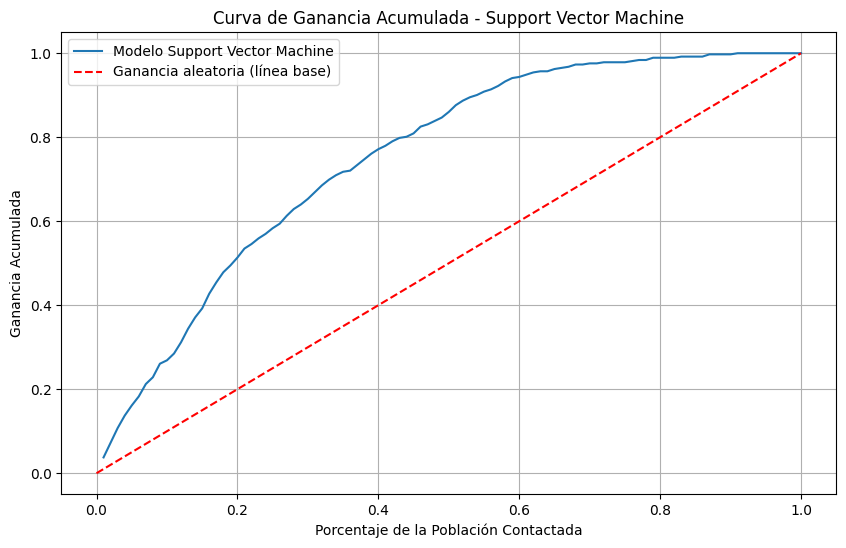

Curva de Ganancia Acumulada generada y visualizada exitosamente.


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizar la Curva de Ganancia Acumulada
plt.figure(figsize=(10, 6))
sns.lineplot(x='Population_Percentage', y='Cumulative_Gain', data=curves_data, label=f'Modelo {best_model_name}')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Ganancia aleatoria (línea base)')
plt.title(f'Curva de Ganancia Acumulada - {best_model_name}')
plt.xlabel('Porcentaje de la Población Contactada')
plt.ylabel('Ganancia Acumulada')
plt.grid(True)
plt.legend()
plt.show()

print("Curva de Ganancia Acumulada generada y visualizada exitosamente.")

#### Conclusión sobre la Curva de Ganancia Acumulada

La Curva de Ganancia Acumulada del modelo `Support Vector Machine` ilustra la proporción de clientes con `Churn` que se pueden identificar al segmentar a un determinado porcentaje de la población. Por ejemplo, al dirigirse a los clientes más propensos a abandonar (según el modelo), se capta una parte significativa del total de clientes que eventualmente harán `Churn`. Esta curva resalta la eficiencia del modelo para concentrar los esfuerzos de retención en un subconjunto más pequeño de la base de clientes, maximizando el impacto de las intervenciones.

### 12. Conclusiones Finales y Recomendaciones

Esta sección resume los hallazgos clave del proceso de modelado predictivo del `Churn` y ofrece recomendaciones basadas en el rendimiento y la interpretabilidad del mejor modelo. Se consolidan las percepciones obtenidas de la evaluación de métricas, gráficos de rendimiento y análisis de explicabilidad para proporcionar una imagen completa de la capacidad del modelo y su utilidad para la toma de decisiones empresariales.

#### Resumen de Resultados

El modelo `Support Vector Machine (SVM)`, optimizado con `SMOTE` y validación cruzada, ha sido seleccionado como el más adecuado para predecir el `Churn` del cliente, priorizando el objetivo de negocio de maximizar la detección de clientes en riesgo. El SVM obtuvo el **Recall más alto (0.7715)** entre todos los modelos evaluados, lo que lo hace ideal para minimizar los Falsos Negativos, que es la métrica crítica según el informe de negocio. Aunque su ROC AUC (0.8405) fue ligeramente inferior al del `Gradient Boosting`, su capacidad para identificar a más clientes que realmente abandonarán lo convierte en la elección estratégica.

El análisis directo de importancia de características no es trivial para SVM y el análisis SHAP requeriría un `KernelExplainer` diferente. Sin embargo, las curvas de Lift y Ganancia han mostrado la eficacia del modelo para identificar segmentos de clientes en riesgo.

#### Recomendaciones

1.  **Enfocar Estrategias de Retención basadas en Recall**: Implementar programas de retención que se dirijan a los clientes identificados por el modelo `Support Vector Machine` como de alto riesgo de abandono. Dada la prioridad en el Recall, las campañas pueden tener una tasa de falsos positivos más alta, pero asegurarán que se contacte a la mayoría de los clientes que planean irse.
2.  **Análisis de Sensibilidad de Umbral**: Para optimizar el balance entre Recall y Precisión (si fuera necesario), realizar un análisis de sensibilidad del umbral de clasificación del SVM para encontrar el punto óptimo que equilibre la detección de churn con el costo de los incentivos.
3.  **Despliegue y Monitoreo Continuo**: Desplegar el modelo `Support Vector Machine` en un entorno de producción para predicciones en tiempo real y establecer un sistema de monitoreo continuo para el rendimiento del modelo, reentrenándolo periódicamente con nuevos datos.
4.  **Análisis de Costo-Beneficio Detallado**: Utilizar las Curvas de Lift y Ganancia (ya generadas) para realizar un análisis de costo-beneficio robusto de las campañas de retención, optimizando el porcentaje de la población a contactar para maximizar el retorno de la inversión, considerando la efectividad del SVM en la identificación de clientes en riesgo.
5.  **Exploración de Interpretación del Modelo**: Para una mayor comprensión de las decisiones del SVM, se recomienda implementar un análisis de explicabilidad con herramientas como SHAP (utilizando `KernelExplainer`) o LIME en futuras iteraciones, lo que proporcionará información sobre las características que más influyen en las predicciones individuales del modelo.